# Assignment 4: Training a DCGAN on Fashion-MNIST

## Objective

Train a Deep Convolutional Generative Adversarial Network (DCGAN) on the Fashion-MNIST dataset.

The experiment will:
- Train a Generator and Discriminator
- Train the model for 30 epochs
- Generate a 4 × 4 image grid every 5 epochs
- Track Generator and Discriminator losses
- Plot the loss curves
- Compare generated images at different stages
- Analyze image quality, recognizable clothing shapes, improvement, plateauing, and mode collapse

In [1]:
# Import required libraries

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image

from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Set random seeds for reproducibility

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [3]:
# Training configuration

BATCH_SIZE = 128
IMAGE_SIZE = 28
CHANNELS = 1

LATENT_DIM = 100

NUM_EPOCHS = 30

LEARNING_RATE = 0.0002
BETA1 = 0.5
BETA2 = 0.999

# Create output directories

os.makedirs("dcgan_outputs", exist_ok=True)
os.makedirs("dcgan_outputs/grids", exist_ok=True)
os.makedirs("dcgan_outputs/checkpoints", exist_ok=True)

print("Configuration completed.")

Configuration completed.


## Fashion-MNIST Dataset

Fashion-MNIST contains 28 × 28 grayscale images of clothing items.

The images are normalized from `[0, 1]` to `[-1, 1]` because the Generator uses a `Tanh` activation function at its output.

In [4]:
# Load and preprocess Fashion-MNIST

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Training images:", len(train_dataset))
print("Number of batches:", len(train_loader))

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 168kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.17MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.0MB/s]

Training images: 60000
Number of batches: 469


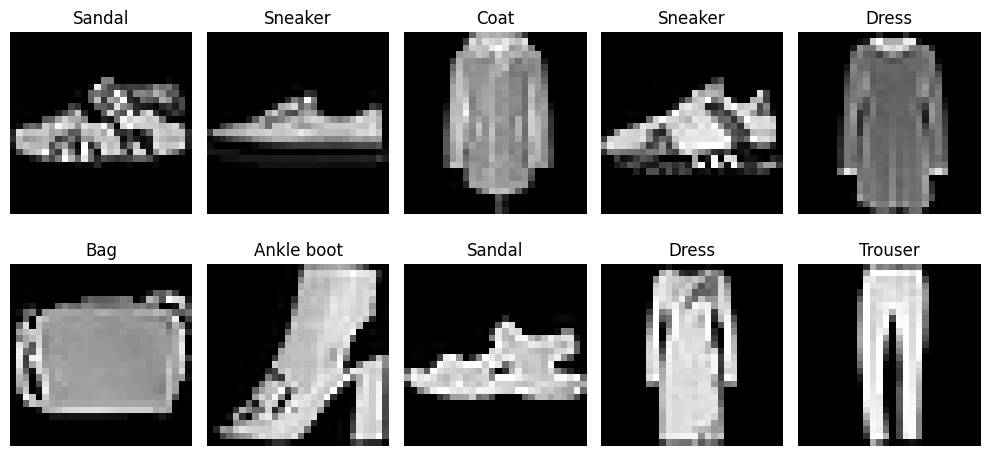

In [5]:
# Display some real Fashion-MNIST images

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    image = images[i].squeeze().numpy()

    # Convert [-1, 1] back to [0, 1]
    image = (image + 1) / 2

    plt.imshow(image, cmap="gray")
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Generator

The Generator converts a random latent vector into a 28 × 28 grayscale image.

Architecture:

100 × 1 × 1  
↓  
128 × 7 × 7  
↓  
64 × 14 × 14  
↓  
1 × 28 × 28

The Generator uses `ConvTranspose2d` layers for upsampling.

In [6]:
# Define Generator

class Generator(nn.Module):

    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            # 100 x 1 x 1 -> 128 x 7 x 7
            nn.ConvTranspose2d(
                latent_dim,
                128,
                kernel_size=7,
                stride=1,
                padding=0,
                bias=False
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 128 x 7 x 7 -> 64 x 14 x 14
            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 64 x 14 x 14 -> 1 x 28 x 28
            nn.ConvTranspose2d(
                64,
                1,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


netG = Generator(LATENT_DIM).to(device)

print(netG)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)


## Discriminator

The Discriminator receives a 28 × 28 image and determines whether it is a real Fashion-MNIST image or a generated image.

It uses convolutional layers followed by LeakyReLU activations.

In [7]:
# Define Discriminator

class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            # 1 x 28 x 28 -> 64 x 14 x 14
            nn.Conv2d(
                1,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 14 x 14 -> 128 x 7 x 7
            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 x 7 x 7 -> 1 x 1 x 1
            nn.Conv2d(
                128,
                1,
                kernel_size=7,
                stride=1,
                padding=0,
                bias=False
            ),

            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)


netD = Discriminator().to(device)

print(netD)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 1, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (6): Sigmoid()
  )
)


## Weight Initialization

DCGAN commonly initializes convolution weights with a normal distribution having mean 0 and standard deviation 0.02.

In [8]:
# Initialize DCGAN weights

def weights_init(model):

    classname = model.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(model.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(model.weight.data, 1.0, 0.02)
        nn.init.constant_(model.bias.data, 0)


netG.apply(weights_init)
netD.apply(weights_init)

print("Weights initialized successfully!")

Weights initialized successfully!


In [9]:
# Loss function and optimizers

criterion = nn.BCELoss()

optimizerG = optim.Adam(
    netG.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

optimizerD = optim.Adam(
    netD.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

print("Loss function and optimizers ready.")

Loss function and optimizers ready.


In [10]:
# Fixed noise for comparing generated images across epochs

fixed_noise = torch.randn(
    16,
    LATENT_DIM,
    1,
    1,
    device=device
)

print("Fixed noise shape:", fixed_noise.shape)

Fixed noise shape: torch.Size([16, 100, 1, 1])


## Training the DCGAN

For each batch:

1. Train the Discriminator using real images.
2. Generate fake images using the Generator.
3. Train the Discriminator using fake images.
4. Train the Generator so that generated images are classified as real.
5. Save a 4 × 4 generated image grid every 5 epochs.

In [11]:
# Train the DCGAN

G_losses = []
D_losses = []

epoch_G_losses = []
epoch_D_losses = []

saved_epochs = []

print("Starting training...\n")

for epoch in range(1, NUM_EPOCHS + 1):

    netG.train()
    netD.train()

    total_G_loss = 0
    total_D_loss = 0

    batch_count = 0

    for real_images, _ in train_loader:

        real_images = real_images.to(device)

        batch_size = real_images.size(0)

        # Real = 1
        # Fake = 0
        real_labels = torch.ones(batch_size, device=device)
        fake_labels = torch.zeros(batch_size, device=device)

        # =====================================================
        # Train Discriminator
        # =====================================================

        netD.zero_grad()

        # Real images
        output_real = netD(real_images)

        loss_D_real = criterion(
            output_real,
            real_labels
        )

        loss_D_real.backward()

        # Generate fake images
        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            1,
            1,
            device=device
        )

        fake_images = netG(noise)

        # Fake images
        output_fake = netD(fake_images.detach())

        loss_D_fake = criterion(
            output_fake,
            fake_labels
        )

        loss_D_fake.backward()

        # Total discriminator loss
        loss_D = loss_D_real + loss_D_fake

        optimizerD.step()

        # =====================================================
        # Train Generator
        # =====================================================

        netG.zero_grad()

        output_fake_for_G = netD(fake_images)

        # Generator wants discriminator to think fake images are real
        loss_G = criterion(
            output_fake_for_G,
            real_labels
        )

        loss_G.backward()

        optimizerG.step()

        # Store losses
        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

        total_G_loss += loss_G.item()
        total_D_loss += loss_D.item()

        batch_count += 1

    # Average losses for the epoch
    avg_G_loss = total_G_loss / batch_count
    avg_D_loss = total_D_loss / batch_count

    epoch_G_losses.append(avg_G_loss)
    epoch_D_losses.append(avg_D_loss)

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}]  "
        f"Generator Loss: {avg_G_loss:.4f}  "
        f"Discriminator Loss: {avg_D_loss:.4f}"
    )

    # =========================================================
    # Save generated images every 5 epochs
    # =========================================================

    if epoch % 5 == 0:

        netG.eval()

        with torch.no_grad():
            generated_images = netG(fixed_noise).cpu()

        grid_path = (
            f"dcgan_outputs/grids/"
            f"generated_epoch_{epoch:02d}.png"
        )

        save_image(
            generated_images,
            grid_path,
            nrow=4,
            normalize=True,
            value_range=(-1, 1),
            padding=2
        )

        saved_epochs.append(epoch)

        # Save checkpoint
        checkpoint_path = (
            f"dcgan_outputs/checkpoints/"
            f"dcgan_epoch_{epoch:02d}.pth"
        )

        torch.save({
            "epoch": epoch,
            "generator": netG.state_dict(),
            "discriminator": netD.state_dict(),
            "optimizerG": optimizerG.state_dict(),
            "optimizerD": optimizerD.state_dict(),
            "G_losses": G_losses,
            "D_losses": D_losses
        }, checkpoint_path)

        print(f"  Saved image grid: Epoch {epoch}")

print("\nTraining completed!")

Starting training...

Epoch [01/30]  Generator Loss: 2.1820  Discriminator Loss: 0.4384
Epoch [02/30]  Generator Loss: 2.0921  Discriminator Loss: 0.4962
Epoch [03/30]  Generator Loss: 1.6578  Discriminator Loss: 0.7153
Epoch [04/30]  Generator Loss: 1.4717  Discriminator Loss: 0.8555
Epoch [05/30]  Generator Loss: 1.4227  Discriminator Loss: 0.8983
  Saved image grid: Epoch 5
Epoch [06/30]  Generator Loss: 1.4093  Discriminator Loss: 0.9070
Epoch [07/30]  Generator Loss: 1.3840  Discriminator Loss: 0.9350
Epoch [08/30]  Generator Loss: 1.3598  Discriminator Loss: 0.9567
Epoch [09/30]  Generator Loss: 1.3553  Discriminator Loss: 0.9755
Epoch [10/30]  Generator Loss: 1.3418  Discriminator Loss: 0.9835
  Saved image grid: Epoch 10
Epoch [11/30]  Generator Loss: 1.3294  Discriminator Loss: 0.9907
Epoch [12/30]  Generator Loss: 1.3170  Discriminator Loss: 1.0176
Epoch [13/30]  Generator Loss: 1.3071  Discriminator Loss: 1.0303
Epoch [14/30]  Generator Loss: 1.3062  Discriminator Loss: 1.01

## Generator Loss Graph

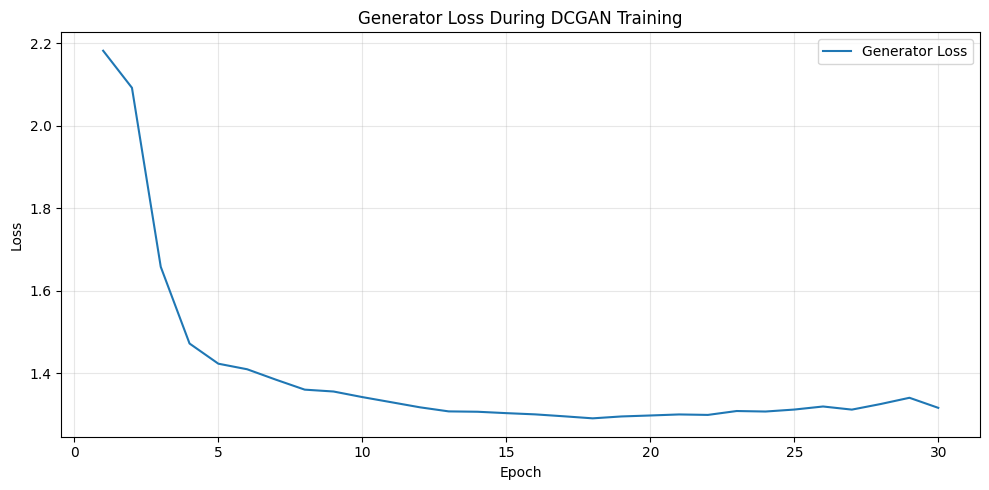

In [12]:
# Plot Generator Loss

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    epoch_G_losses,
    label="Generator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator Loss During DCGAN Training")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "dcgan_outputs/generator_loss.png",
    dpi=200
)

plt.show()

## Discriminator Loss Graph

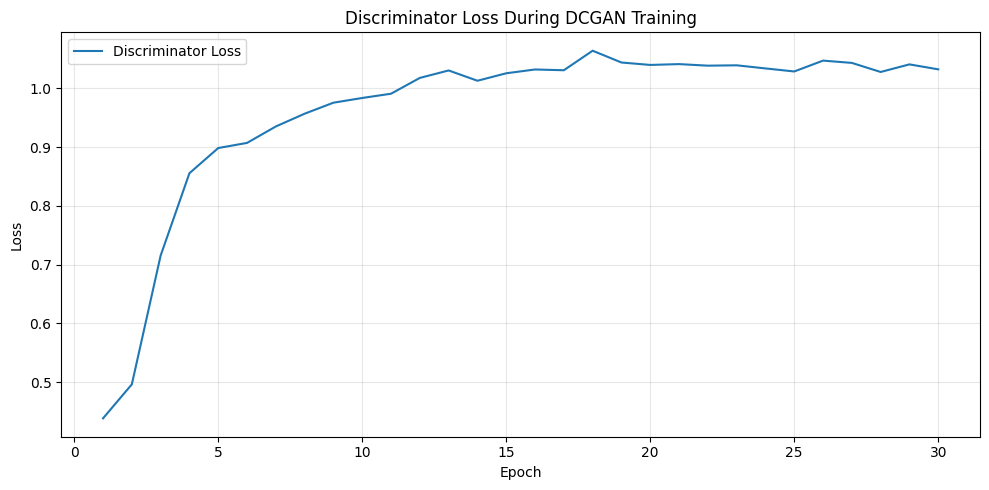

In [13]:
# Plot Discriminator Loss

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    epoch_D_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Discriminator Loss During DCGAN Training")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "dcgan_outputs/discriminator_loss.png",
    dpi=200
)

plt.show()

## Combined Generator and Discriminator Loss

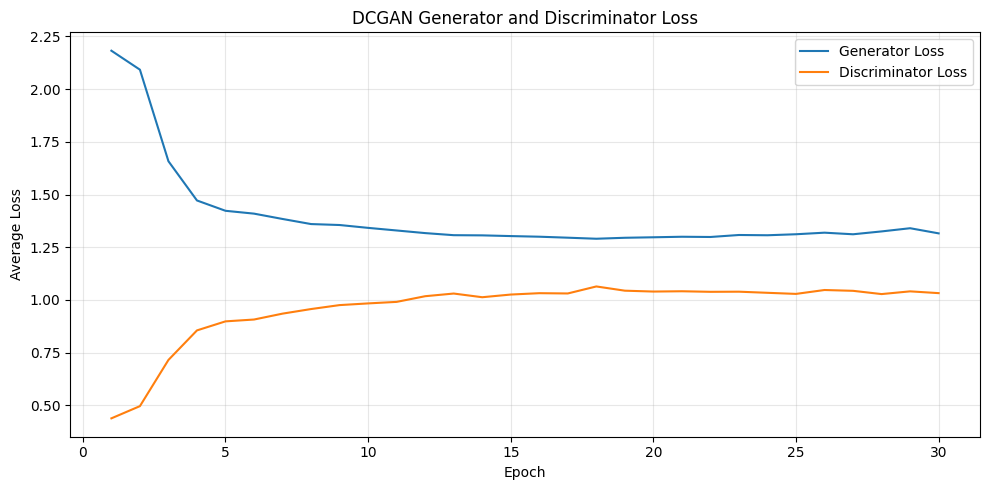

In [14]:
# Plot both losses together

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    epoch_G_losses,
    label="Generator Loss"
)

plt.plot(
    epochs,
    epoch_D_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("DCGAN Generator and Discriminator Loss")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "dcgan_outputs/loss_graph.png",
    dpi=200
)

plt.show()

## Generated Images at Different Epochs

The following cell displays the generated 4 × 4 image grids saved at epochs 5, 10, 15, 20, 25, and 30.

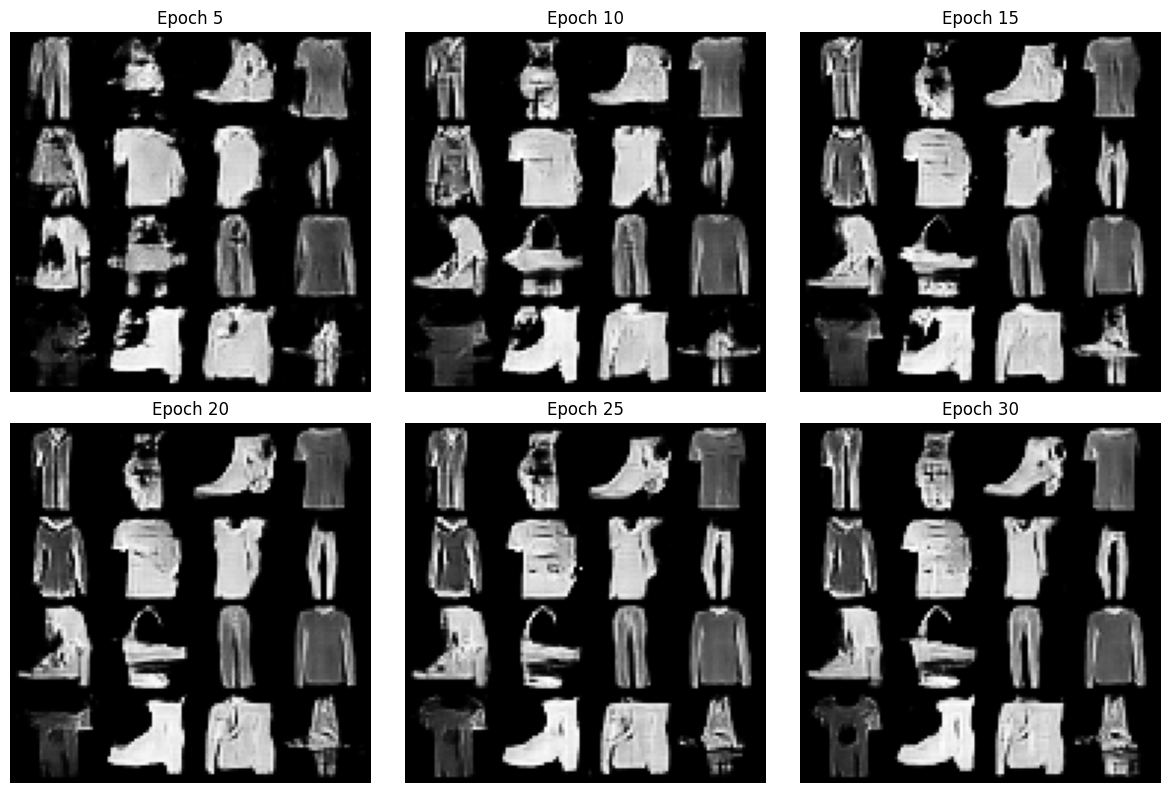

In [15]:
# Display generated image grids

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8)
)

for ax, epoch in zip(
    axes.ravel(),
    saved_epochs
):

    path = (
        f"dcgan_outputs/grids/"
        f"generated_epoch_{epoch:02d}.png"
    )

    image = Image.open(path)

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Epoch {epoch}")
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    "dcgan_outputs/generated_progression.png",
    dpi=200
)

plt.show()

## Final Generated Samples

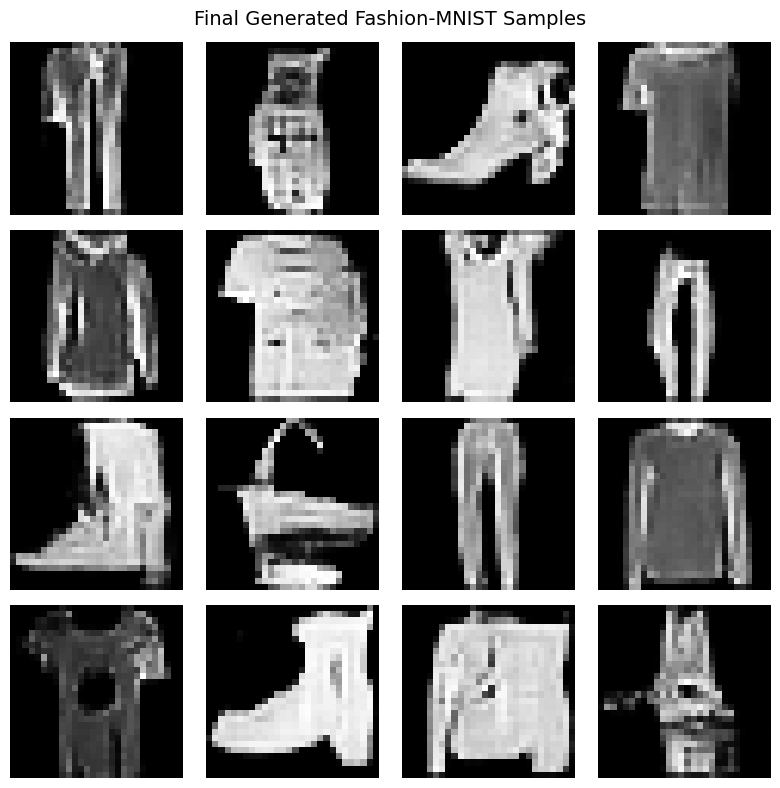

In [16]:
# Generate final samples

netG.eval()

with torch.no_grad():

    final_images = netG(
        fixed_noise
    ).cpu()

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    image = final_images[i].squeeze().numpy()

    # Convert [-1, 1] to [0, 1]
    image = (image + 1) / 2

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Final Generated Fashion-MNIST Samples",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "dcgan_outputs/final_samples.png",
    dpi=200
)

plt.show()

In [17]:
# Save losses into a CSV file

import csv

csv_path = "dcgan_outputs/losses.csv"

with open(
    csv_path,
    "w",
    newline=""
) as file:

    writer = csv.writer(file)

    writer.writerow([
        "Epoch",
        "Generator Loss",
        "Discriminator Loss"
    ])

    for epoch, g_loss, d_loss in zip(
        epochs,
        epoch_G_losses,
        epoch_D_losses
    ):

        writer.writerow([
            epoch,
            g_loss,
            d_loss
        ])

print("Loss data saved to:", csv_path)

Loss data saved to: dcgan_outputs/losses.csv


# Analysis and Observations

## 1. Early Training

During the first few epochs, the generated images are usually noisy, blurry, and poorly structured. The Generator has not yet learned the visual patterns associated with clothing.

## 2. Improvement During Training

As training progresses, the Generator begins to learn general shapes and structures from Fashion-MNIST. Images should gradually become more recognizable and clothing-like.

## 3. Recognizable Clothing Shapes

Compare the generated grids at epochs 5, 10, 15, 20, 25, and 30. Identify the approximate epoch at which recognizable shapes such as shoes, shirts, trousers, bags, or coats begin to appear.

## 4. Image Quality

Observe whether image quality continues improving throughout the 30 epochs or whether it begins to plateau during the later epochs.

## 5. Mode Collapse

Check whether many generated images look almost identical. If several samples become very similar, this may indicate mode collapse. If the samples remain visually diverse, there is no obvious severe mode collapse.

## 6. Training Stability

GAN losses do not necessarily decrease smoothly. Fluctuations are normal because the Generator and Discriminator continuously compete against each other.

## 7. Final Conclusion

The DCGAN demonstrates how a Generator can learn to create Fashion-MNIST-like images from random noise while the Discriminator learns to distinguish generated images from real images.

# Final Observation

The DCGAN was trained on the Fashion-MNIST dataset for 30 epochs. During the early epochs, the generated images were noisy, blurry, and had very little recognizable clothing structure.

Recognizable clothing-like shapes started appearing around epoch 10.

As training progressed, the generated images became clearer, more structured, and more similar to Fashion-MNIST clothing items. The improvement was particularly noticeable between epochs 10 and 25.

By epoch 30, the image quality had improved compared with the early epochs, although some images were still blurry and lacked fine details.

The Generator loss fluctuated throughout training while the Discriminator loss also fluctuated rather than decreasing smoothly. This behavior is expected because the Generator and Discriminator continuously compete against each other during GAN training.

The generated samples showed reasonable diversity, indicating no obvious severe mode collapse. However, some generated images had similar shapes, which can occur during GAN training.

Overall, the experiment demonstrated that the DCGAN was able to learn meaningful visual patterns from Fashion-MNIST and gradually generate recognizable clothing-like images from random noise. The results also showed that GAN training can be unstable and that visual inspection of generated samples is important when evaluating the model.